Points found: 311


,timestep,XfrA_avg,XfrC_avg,Anode_current,Cathode_current,Anode_target,Cathode_target,VCell,BvA,BvC,BvE,Ce_min,Ce_max
0,0,0.950000,0.300000,-9.449560e-13,9.491930e-13,5.387380e-12,4.623150e-12,3.96979,-0.00999,3.95980,-0.1,0.000001,0.001000
1,1000,0.948638,0.301501,-3.750590e-12,4.774230e-12,5.387380e-12,4.623150e-12,3.86483,-0.00741,3.85742,-0.1,0.000999,0.001011
2,2000,0.947088,0.303392,-3.703250e-12,4.807180e-12,5.387380e-12,4.623150e-12,3.84071,-0.00729,3.83342,-0.1,0.000999,0.001011
3,3000,0.945529,0.305296,-3.680370e-12,4.806190e-12,5.387380e-12,4.623150e-12,3.82297,-0.00715,3.81582,-0.1,0.000999,0.001011
4,4000,0.943965,0.307204,-3.662520e-12,4.797550e-12,5.387380e-12,4.623150e-12,3.80804,-0.00701,3.80103,-0.1,0.000999,0.001011


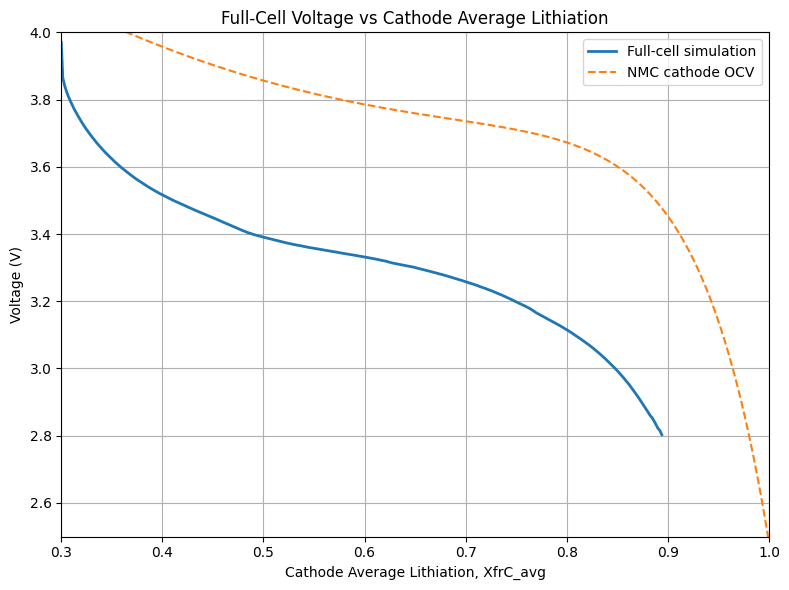

In [17]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD THE FULL-CELL SLURM OUTPUT
# ============================================================

# # Option A: Paste your complete SLURM output between the triple quotes.
# log_text = r"""
# PASTE YOUR FULL SLURM OUTPUT HERE
# """

# Option B: Read the output directly from a file instead.
# Uncomment this section and update the path if preferred.
#
file_path = "../MSU_HPCC/Full-cell-NMC-graphite-13730245.SLURMout"
with open(file_path, "r") as file:
    log_text = file.read()


# ============================================================
# STEP 2: PARSE FULL-CELL TIMESTEP LINES
# ============================================================

# This extracts values from lines such as:
#
# timestep: 1000 [FULL-CELL],
# XfrA_avg = 0.948638,
# XfrC_avg = 0.301501,
# Anode current = ...,
# Cathode current = ...,
# ...
# VCell = 3.86483,
# BvA = ...,
# BvC = ...,
# ...

timestep_pattern = re.compile(
    r"timestep:\s*(\d+)\s*\[FULL-CELL\],"
    r".*?XfrA_avg\s*=\s*([-+eE0-9.]+),"
    r".*?XfrC_avg\s*=\s*([-+eE0-9.]+),"
    r".*?Anode current\s*=\s*([-+eE0-9.]+),"
    r".*?Cathode current\s*=\s*([-+eE0-9.]+),"
    r".*?Anode target\s*=\s*([-+eE0-9.]+),"
    r".*?Cathode target\s*=\s*([-+eE0-9.]+),"
    r".*?VCell\s*=\s*([-+eE0-9.]+),"
    r".*?BvA\s*=\s*([-+eE0-9.]+),"
    r".*?BvC\s*=\s*([-+eE0-9.]+),"
    r".*?BvE\s*=\s*([-+eE0-9.]+),"
    r".*?Ce_min\s*=\s*([-+eE0-9.]+),"
    r".*?Ce_max\s*=\s*([-+eE0-9.]+)",
    re.MULTILINE
)

matches = timestep_pattern.findall(log_text)

columns = [
    "timestep",
    "XfrA_avg",
    "XfrC_avg",
    "Anode_current",
    "Cathode_current",
    "Anode_target",
    "Cathode_target",
    "VCell",
    "BvA",
    "BvC",
    "BvE",
    "Ce_min",
    "Ce_max",
]

df = pd.DataFrame(matches, columns=columns)

if df.empty:
    raise ValueError(
        "No full-cell timestep data were found. "
        "Check that the SLURM output was pasted into log_text."
    )

# Convert all extracted values to numbers.
df = df.astype(float)
df["timestep"] = df["timestep"].astype(int)

# Sort in case the output was not pasted chronologically.
df = df.sort_values("timestep").reset_index(drop=True)

print(f"Points found: {len(df)}")
display(df.head())


# ============================================================
# STEP 3: DEFINE THE NMC OCV FUNCTION
# ============================================================

def ocv_function(c):
    """
    NMC open-circuit voltage as a function of cathode lithiation.
    """
    c = np.asarray(c, dtype=float)

    return (
        1.095 * c**2
        - 8.234e-7 * np.exp(14.31 * c)
        + 4.692 * np.exp(-0.5389 * c)
    )


# Smooth OCV curve over the desired concentration range.
c_vals = np.linspace(0.01, 1.0, 500)
ocv_vals = ocv_function(c_vals)

# OCV evaluated at each simulated cathode lithiation.
df["NMC_OCV"] = ocv_function(df["XfrC_avg"])

# Difference between simulated full-cell voltage and cathode OCV.
df["VCell_minus_OCV"] = df["VCell"] - df["NMC_OCV"]


# ============================================================
# STEP 4: PLOT VCELL VS CATHODE AVERAGE LITHIATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    df["XfrC_avg"],
    df["VCell"],
    # marker="o",
    # markersize=2,
    linewidth=2,
    label="Full-cell simulation",
)

plt.plot(
    c_vals,
    ocv_vals,
    "--",
    linewidth=1.5,
    label="NMC cathode OCV",
)

plt.xlabel("Cathode Average Lithiation, XfrC_avg")
plt.ylabel("Voltage (V)")
plt.xlim(0.3, 1.0)
plt.ylim(2.5, 4.0)
plt.title("Full-Cell Voltage vs Cathode Average Lithiation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()